<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_2/blob/main/01_2_OpenCV_%EC%83%89%EC%83%81_%EA%B2%80%EC%B6%9C_%EB%B0%8F_%ED%9E%88%EC%8A%A4%ED%86%A0%EA%B7%B8%EB%9E%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# opencv 설치
!pip install opencv-python

1. 색상에 대해서 히스토그램 그리기
2. 색상에 대해서 마스크 적용하기

In [3]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [4]:
%pwd

'/content'

In [8]:
path = '/content/wafer.jpg'
# 사진 변경시 수정

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
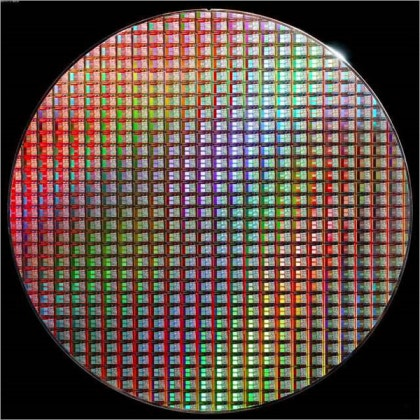

In [9]:
src = cv2.imread(path)
src

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
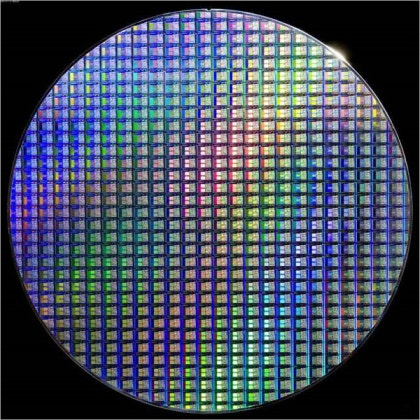

In [10]:
cv2.cvtColor(src, cv2.COLOR_BGR2RGB)

array([[162, 126, 134, ..., 115, 110, 162],
       [139,  75,  74, ...,   0,  12, 106],
       [120,  22,  21, ...,   0,   5, 112],
       ...,
       [117,   0,   0, ...,   1,   1, 114],
       [108,  11,   2, ...,   1,   6, 109],
       [158, 109, 106, ..., 114, 108, 161]], dtype=uint8)
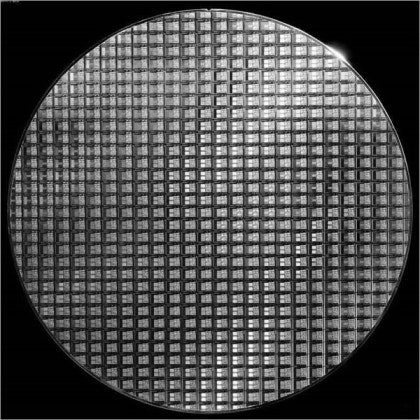

In [11]:
cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

In [12]:
src = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)

In [13]:
# cv2.calcHist() 히스토그램 계산 함수
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# 0번 채널
# None: 마스크 설정이 None (전체 이미지 사용)
# [256] : bin (계급구간) 개수 (0~255 총 256개 구간), 픽셀의 범위 (0~255)


hist[250]
# 밝기의 값이 250인 pixel 개수

array([30.], dtype=float32)

In [14]:
print(hist[0])      # 0  : 검은 구간
print(hist[255])    # 255 : 하얀 구간

# 이 이미지는 대부분 검정
# 보정을 한다면, 명도(빛의 밝기) 높이고,
# 컬러사진이라면 채도를 높이는 작업이 필요하겠다는 판단 가능

[10619.]
[1.]


In [15]:
hist[0, 0]
# 행렬의 가장 첫번째 값

np.float32(10619.0)

In [16]:
# x좌표 (pixel 값 범위 0~255)
# channel : 분석할 채널 (예: grayscale [0] 지점)
# histSize :  히스토그램 구간 수 (0~255: 256개 구간)
# histRange : pixel 값 범위 (0-255)

hist_size = [256]
hist_range = [0, 256]
# 파이썬 range 범위 지정할 때 마지막 뒷 숫자는 미포함

# opencv 함수
hist = cv2.calcHist([src], [0], None, [256], [0, 256])
# (이미지, 채널, None, x가 몇 개로 나누어져 있는가, x 범위)

In [17]:
hist_max = np.max(hist)
hist_max
# 어느 픽셀이 가장 많이 있는가 (최댓값 카운트)

np.float32(27511.0)

In [18]:
# 1단계
x = 0 # 완전 검은색
hist[x,0]
# np.float32(10619.0) >> 10619개

np.float32(10619.0)

In [19]:
# 2단계 : 최댓값 대비 비율 (0-1 사이)
# 3단계 : 퍼센트로 변환 (백분율, 0-100)
(hist[x,0] / hist_max) * 100

np.float32(38.599106)

In [20]:
# 4단계 : 정수로 변환
int((hist[x,0] / hist_max) * 100)

38

In [21]:
# 5단계 : y좌표 계산 (아래에서 위)
# 100에서 빼는 이유 >> 컴퓨터 y축은 일반 수학 y 축과 반전되어 있음.

100 - int((hist[x,0] / hist_max) * 100)   # 62

62

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
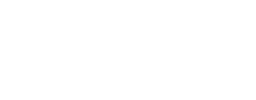

In [22]:
# 그래프 그릴 도화지
# 255(흰색) 채워진 100*256 도화지 준비해주세요
np.full((100,256),255,dtype=np.uint8)

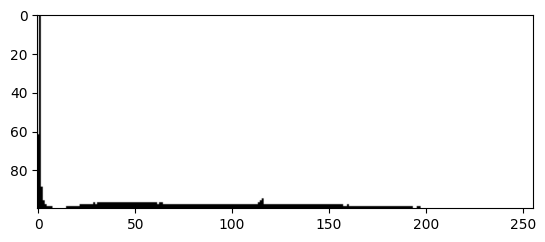

In [23]:
image_bg = np.full((100,256),255,dtype=np.uint8)

for x in range(256):
    # 시작점 pt1
    pt1 = (x, 100)
    # 컴퓨터는 y축이 반전되어 있음. 높이가 100인 도화지를 준비하였으므로 y = 100은 실제로는 0을 의미.

    # 끝점 pt2
    pt2 = (x, 100 - int((hist[x,0] / hist_max) * 100))

    # cv2.line(이미지, 시작점, 끝점, 색상)
    cv2.line(image_bg, pt1, pt2, 0)

plt.imshow(image_bg, cmap='gray')
plt.show()

pt(x, 100) 의미

- x=0 >> (0,100) (밝기 0 (왼쪽 끝) 아래쪽)
- x=50 >> (50,100) (밝기 50 위치에서 아래쪽)
- x=100 >> (100,100) (밝기 100 위치에서 아래쪽)

일반적으로 히스토그램 (밝기, 개수) 형태임 가로축 (x축) : pixel 밝기 값 위치

- x=0 (아주 어두운 픽셀)
- x=128 (중간 밝기)
- x=255 (아주 밝은 픽셀)

마스크 (색상 마스크)

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
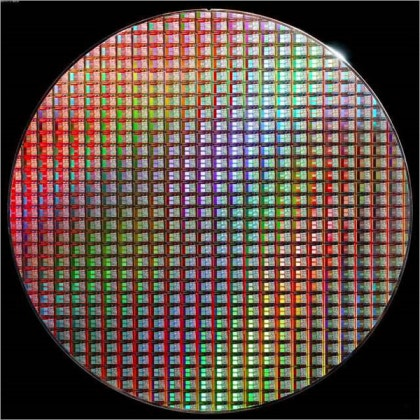

In [24]:
# 색공간 (HSV)

cv2.imread(path)

array([[[162, 162, 162],
        [126, 126, 126],
        [134, 134, 134],
        ...,
        [115, 115, 115],
        [110, 110, 110],
        [162, 162, 162]],

       [[139, 139, 139],
        [ 75,  75,  75],
        [ 74,  74,  74],
        ...,
        [  0,   0,   0],
        [ 12,  12,  12],
        [106, 106, 106]],

       [[120, 120, 120],
        [ 22,  22,  22],
        [ 21,  21,  21],
        ...,
        [  0,   0,   0],
        [  5,   5,   5],
        [112, 112, 112]],

       ...,

       [[117, 117, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [114, 114, 114]],

       [[108, 108, 108],
        [ 11,  11,  11],
        [  2,   2,   2],
        ...,
        [  1,   1,   1],
        [  6,   6,   6],
        [109, 109, 109]],

       [[158, 158, 158],
        [109, 109, 109],
        [106, 106, 106],
        ...,
        [114, 114, 114],
        [108, 108, 108],
        [161, 161, 161]]], dtype=uint8)
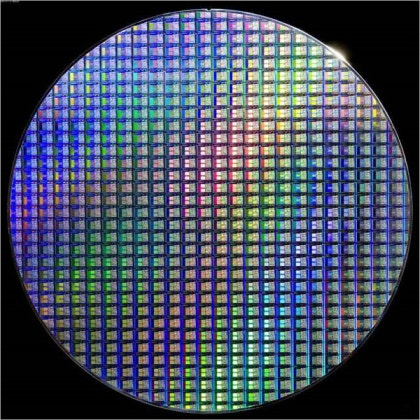

In [26]:
image = cv2.imread(path)
cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

array([[[  0,   0, 162],
        [  0,   0, 126],
        [  0,   0, 134],
        ...,
        [  0,   0, 115],
        [  0,   0, 110],
        [  0,   0, 162]],

       [[  0,   0, 139],
        [  0,   0,  75],
        [  0,   0,  74],
        ...,
        [  0,   0,   0],
        [  0,   0,  12],
        [  0,   0, 106]],

       [[  0,   0, 120],
        [  0,   0,  22],
        [  0,   0,  21],
        ...,
        [  0,   0,   0],
        [  0,   0,   5],
        [  0,   0, 112]],

       ...,

       [[  0,   0, 117],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   1],
        [  0,   0,   1],
        [  0,   0, 114]],

       [[  0,   0, 108],
        [  0,   0,  11],
        [  0,   0,   2],
        ...,
        [  0,   0,   1],
        [  0,   0,   6],
        [  0,   0, 109]],

       [[  0,   0, 158],
        [  0,   0, 109],
        [  0,   0, 106],
        ...,
        [  0,   0, 114],
        [  0,   0, 108],
        [  0,   0, 161]]], dtype=uint8)
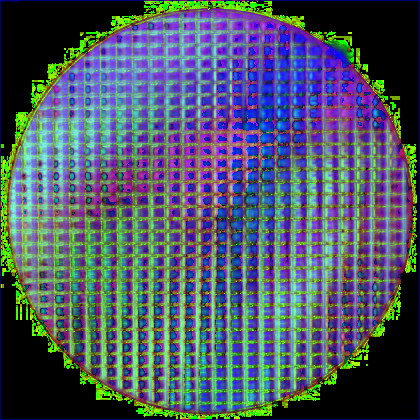

In [28]:
cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# HSV (Hue, Saturation, Value >> 색상, 채도, 명도)
# >>> 색상 분리하기 위해

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
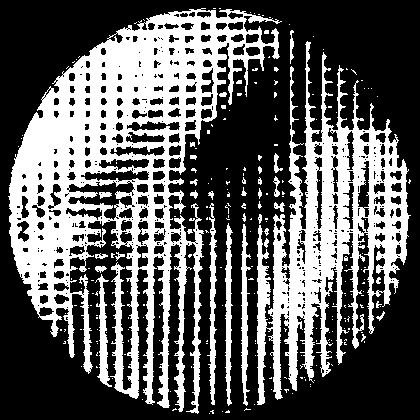

In [35]:
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# 파란색만 추출하기
# 파란색 범위(2개) 지정

lower_blue = np.array([90, 50, 50])
high_blue = np.array([130, 255, 255])

# 마스크 색상
cv2.inRange(hsv, lower_blue, high_blue)
# >> 범위 내의 파란색은 흰색, 그 외의 색은 검정색 변환
# >> inRange() 결과는 True(255, 흰색) or False(0, 검정색)

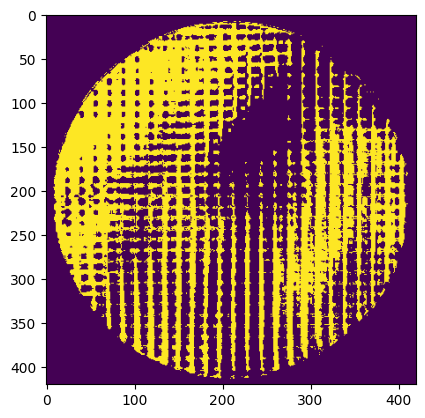

In [37]:
mask = cv2.inRange(hsv, lower_blue, high_blue)

plt.imshow(mask)
plt.show()

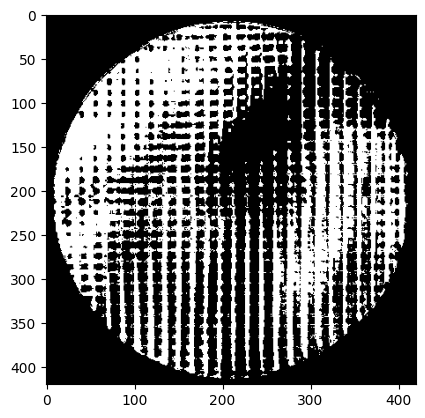

In [38]:
plt.imshow(mask, cmap='gray')
plt.show()

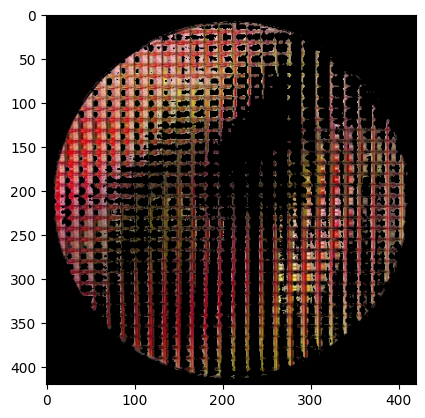

In [40]:
# AND 연산자
result = cv2.bitwise_and(image, image, mask=mask)

plt.imshow(result)
plt.show()
# 결과 빨간색 출력
# >> matplot과 opencv의 색상 해석 순서 때문. matplot:R → G → B, opencv:B → G → R
# >> result 이미지 형식을 RGB로 변형해주어야

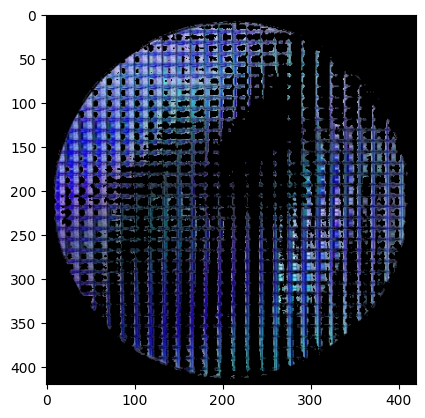

In [41]:
result = cv2.bitwise_and(image, image, mask=mask)

dst = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.imshow(dst)
plt.show()

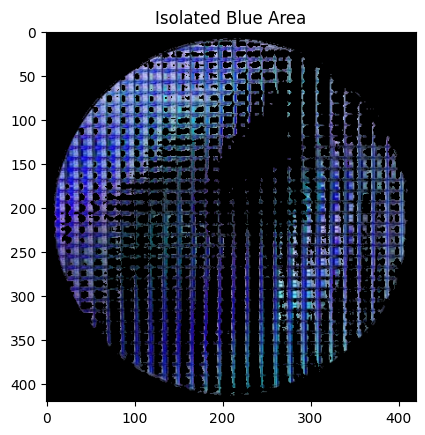

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(path)
src = image.copy()
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

lower_blue = np.array([90, 50, 50])
high_blue = np.array([130, 255, 255])

mask = cv2.inRange(hsv, lower_blue, high_blue)
dst = cv2.bitwise_and(src, src, mask=mask)
dst_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)

plt.imshow(dst_rgb)
plt.title('Isolated Blue Area')
plt.show()

In [ ]:
# eos